In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report


In [3]:
df = pd.read_pickle("/Users/a./Wafer_project/wafer-defects/data/labeled.pkl")
df.shape

(172950, 2)

In [4]:
np.linspace(0, 3, 8)

array([0.        , 0.42857143, 0.85714286, 1.28571429, 1.71428571,
       2.14285714, 2.57142857, 3.        ])

In [5]:
np.linspace(0, 3, 8).round().astype(int)

array([0, 0, 1, 1, 2, 2, 3, 3])

In [6]:
def resize_map(wafer,size = 64):
    rows = np.linspace(0,wafer.shape[0]-1,size).round().astype(int)
    cols = np.linspace(0,wafer.shape[1]-1,size).round().astype(int)
    return wafer[rows][:, cols]

In [7]:
w = df.iloc[0]["waferMap"]
small = resize_map(w)
print(w.shape, small.shape)
print(np.unique(small))

(45, 48) (64, 64)
[0 1 2]


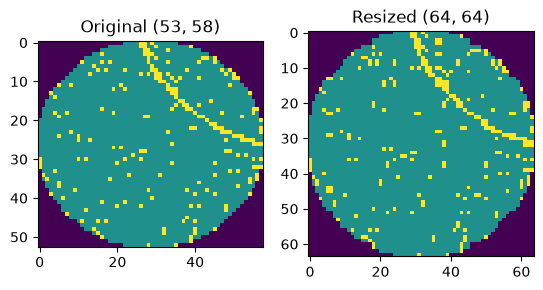

In [8]:
w = df[df["label"]== "Scratch"].iloc[0]["waferMap"]

fig, axes = plt.subplots(1, 2)
axes[0].imshow(w)
axes[0].set_title(f"Original {w.shape}")
axes[1].imshow(resize_map(w))
axes[1].set_title("Resized (64, 64)")
plt.show()

In [9]:
X = np.stack(df["waferMap"].apply(resize_map).to_list()).astype(np.uint8)
y = df["label"].to_numpy()

In [10]:
print(X.shape)
print(y.shape)


(172950, 64, 64)
(172950,)


In [11]:
none_sample = df[df["label"] == "none"].sample(n=10000, random_state = 69)
defects = df[df["label"]!= "none"]
df_bal = pd.concat([defects, none_sample])

In [12]:
df_bal.shape

(35519, 2)

In [13]:
X = np.stack(df_bal["waferMap"].apply(resize_map).to_list()).astype(np.uint8)
y = df_bal["label"].to_numpy()
X_flat = X.reshape(len(X), -1)

In [14]:
print(X.shape)
print(X_flat.shape)
print(y.shape)

(35519, 64, 64)
(35519, 4096)
(35519,)


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X_flat, y, test_size=0.2, stratify= y, random_state=67
)
print(X_train.shape, X_test.shape)

(28415, 4096) (7104, 4096)


In [16]:
model = RandomForestClassifier(n_estimators = 100, n_jobs =-1, random_state = 68)
model.fit(X_train,y_train)


,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",68
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [17]:
y_pred = model.predict(X_test)
accuracy = (y_pred == y_test).mean()
accuracy


np.float64(0.7989864864864865)

In [18]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      Center       0.94      0.89      0.91       859
       Donut       0.92      0.60      0.73       111
    Edge-Loc       0.75      0.66      0.70      1038
   Edge-Ring       0.98      0.96      0.97      1936
         Loc       0.70      0.27      0.39       719
   Near-full       0.96      0.77      0.85        30
      Random       0.91      0.53      0.67       173
     Scratch       0.77      0.08      0.15       238
        none       0.66      0.99      0.79      2000

    accuracy                           0.80      7104
   macro avg       0.84      0.64      0.69      7104
weighted avg       0.81      0.80      0.78      7104



# The random forest got 8% recall on scratches because it treats each pixel as an independent feature, so it can't recognize a pattern that moves around. That motivated the CNN.


## Summary

- Preprocessing: resized every wafer map to 64x64 using nearest neighbor, so all inputs have the same size and values stay 0/1/2
  
- Undersampling: kept all 25,519 defect wafers + 10,000 random "none" wafers (35,519 total), to fit in 8 GB RAM and reduce imbalance ("none" went from 85.2% to 28.2%)
  
- Split: 80% train (28,415) / 20% test (7,104), stratified so every class keeps the same proportion in both sets

  
- Model: random forest, 100 trees, on flattened maps (4,096 features per wafer)
- Result: 79.9% accuracy, macro recall 0.64

  
- Weak spots: Scratch recall 0.08, Loc recall 0.27. Likely because the forest treats each pixel as an independent feature at a fixed position, so it can't learn patterns that move around the wafer. Most missed defects get predicted as "none" (precision

#Taking data into notebook 3

In [19]:
np.save("/Users/a./Wafer_project/wafer-defects/data/X.npy", X)
np.save("/Users/a./Wafer_project/wafer-defects/data/y.npy", y.astype(str))